# Zombie Vortex Instability (ZVI) Analysis: Perturbation Spectrum and Wave Packet Ray Tracing

This notebook analyzes the Zombie Vortex Instability in a cylindrical coordinate system with a background Lamb-Oseen vortex. It consists of two main components:

1. **Perturbation Spectrum Analyzer**: Analyzes the spectral content of an initial Gaussian vortex perturbation to identify dominant wave modes.
2. **Wave Packet Ray Tracer**: Traces the energy propagation paths of specific wave modes through the background vortex using WKB ray tracing.

## Background Theory

The Zombie Vortex Instability arises when an internal wave packet propagates through a rotating stratified vortex and deposits its energy at a critical layer, causing the vortex to spontaneously generate new waves in a sustained cycle.

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftn, fftfreq, fftshift
from scipy.optimize import fsolve, brentq
from dataclasses import dataclass
from typing import Tuple, List, Optional
import warnings

# Set plot style
plt.style.use('default')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print("Imports successful!")

Imports successful!


## Component 1: Perturbation Spectrum Analyzer

This component analyzes the spectral content of a Gaussian vortex perturbation placed in the background Lamb-Oseen vortex.

In [2]:
@dataclass
class BackgroundParams:
    """Global background parameters"""
    Omega_bg: float  # Background rotation rate
    N: float  # Brunt-Väisälä frequency
    V_max: float  # Maximum velocity of Lamb-Oseen vortex
    r_core: float  # Core radius of Lamb-Oseen vortex


@dataclass
class PerturbationParams:
    """Gaussian vortex perturbation parameters"""
    r0: float  # Radial position
    theta0: float  # Azimuthal position (radians)
    z0: float  # Vertical position
    Ro_pert: float  # Local Rossby number of perturbation
    L_prime: float  # Horizontal length scale
    N_prime_c: float  # Core stratification of perturbation
    

class LambOseenVortex:
    """Lamb-Oseen vortex background flow"""
    
    def __init__(self, V_max: float, r_core: float):
        """
        Initialize Lamb-Oseen vortex.
        
        V_theta(r) = V_max * (1 - exp(-r^2/r_core^2)) / (r/r_core)
        
        Parameters:
        -----------
        V_max : float
            Maximum azimuthal velocity
        r_core : float
            Core radius
        """
        self.V_max = V_max
        self.r_core = r_core
        
    def V_theta(self, r: np.ndarray) -> np.ndarray:
        """Azimuthal velocity profile"""
        r = np.atleast_1d(r)
        r_normalized = r / self.r_core
        
        # Avoid division by zero at r=0
        V = np.zeros_like(r)
        mask = r > 1e-10
        V[mask] = self.V_max * (1 - np.exp(-r_normalized[mask]**2)) / r_normalized[mask]
        
        return V
    
    def Omega_bar(self, r: np.ndarray) -> np.ndarray:
        """Angular velocity Omega = V_theta / r"""
        r = np.atleast_1d(r)
        V = self.V_theta(r)
        
        Omega = np.zeros_like(r)
        mask = r > 1e-10
        Omega[mask] = V[mask] / r[mask]
        
        return Omega
    
    def sigma_shear(self, r: np.ndarray) -> np.ndarray:
        """
        Shear rate: sigma = r * d/dr(V_theta/r) = r * (-r^-2 * V_theta + r^-1 * dV_theta/dr) = -Omega + dOmega/dr
        
        For Lamb-Oseen: sigma = (2*V_max/r_core^2) * exp(-r^2/r_core^2)
        """
        r = np.atleast_1d(r)
        r_normalized = r / self.r_core
        
        return (2 * self.V_max / self.r_core**2) * np.exp(-r_normalized**2)
    
    def f_eff(self, r: np.ndarray, Omega_bg: float) -> np.ndarray:
        """
        Effective Coriolis frequency: f_eff = (1/r) * d/dr(r^2 * Omega_total)
        where Omega_total = Omega_bg + V_theta/r
        """
        r = np.atleast_1d(r)
        
        # f_eff = 2*Omega_bg + 2*V_theta/r + r*dV_theta/dr - V_theta
        # For Lamb-Oseen, this simplifies to:
        # f_eff = 2*Omega_bg + sigma_shear
        
        return 2 * Omega_bg + self.sigma_shear(r)
    
    def dOmega_bar_dr(self, r: np.ndarray) -> np.ndarray:
        """
        Analytical derivative dΩ̄/dr for Lamb-Oseen vortex.
        
        Ω̄ = V_theta / r, so dΩ̄/dr = (dV_theta/dr)/r - V_theta/r²
        """
        r = np.atleast_1d(r)
        result = np.zeros_like(r)
        
        mask = r > 1e-10
        r_masked = r[mask]
        r_norm = r_masked / self.r_core
        exp_term = np.exp(-r_norm**2)
        
        # V_theta
        V_theta = self.V_max * (1 - exp_term) / r_norm
        
        # dV_theta/dr
        dV_theta_dr = self.V_max * (
            (2 * r_masked / self.r_core**2) * exp_term * r_norm - (1 - exp_term) / self.r_core
        ) / r_norm**2
        
        # dΩ̄/dr = (dV_theta/dr)/r - V_theta/r²
        result[mask] = dV_theta_dr / r_masked - V_theta / r_masked**2
        
        return result
    
    def dV_theta_dr(self, r: np.ndarray) -> np.ndarray:
        """
        Analytical derivative dV_θ/dr for Lamb-Oseen vortex.
        """
        r = np.atleast_1d(r)
        result = np.zeros_like(r)
        
        mask = r > 1e-10
        r_masked = r[mask]
        r_norm = r_masked / self.r_core
        exp_term = np.exp(-r_norm**2)
        
        result[mask] = self.V_max * (
            (2 * r_masked / self.r_core**2) * exp_term * r_norm - (1 - exp_term) / self.r_core
        ) / r_norm**2
        
        return result
    
    def zeta(self, r: np.ndarray) -> np.ndarray:
        """
        Compute ζ(r) = Ω̄ + dV̄_θ/dr
        
        This is the shear-related quantity appearing in the dispersion relation.
        """
        return self.Omega_bar(r) + self.dV_theta_dr(r)
    
    def critical_layer_radius_quasi_stationary(self, m: int, N: float) -> List[float]:
        """
        Find critical layer radii for quasi-stationary waves (ω ≈ 0).
        
        For quasi-stationary waves with Φ ≈ i·m·Ω̄:
        Critical layer condition: m·Ω̄(r) = ±N
        → Ω̄ = ±N/m
        
        Need to search for both positive and negative target values.
        
        Parameters:
        -----------
        m : int
            Azimuthal mode number
        N : float
            Brunt-Väisälä frequency
            
        Returns:
        --------
        r_critical : list
            List of critical layer radii for quasi-stationary waves
        """
        if m == 0:
            return []
        
        # Search for radii where m·Omega(r) = ±N
        # This gives Omega(r) = ±N/m
        target_Omega_pos = N / m  # Positive target (note: keep sign of m)
        target_Omega_neg = -N / m  # Negative target
        
        # Search for radii
        r_search = np.linspace(0.1, 10 * self.r_core, 1000)
        Omega_profile = self.Omega_bar(r_search)
        
        # Find crossings for both targets
        critical_radii = []
        from scipy.optimize import brentq
        
        for target_Omega in [target_Omega_pos, target_Omega_neg]:
            for i in range(len(r_search) - 1):
                diff_i = Omega_profile[i] - target_Omega
                diff_ip1 = Omega_profile[i+1] - target_Omega
                
                if diff_i * diff_ip1 < 0:
                    # Zero crossing detected, refine with root finding
                    try:
                        r_c = brentq(lambda r: self.Omega_bar(np.array([r]))[0] - target_Omega,
                                    r_search[i], r_search[i+1], xtol=1e-8)
                        critical_radii.append(r_c)
                    except:
                        pass
        
        return sorted(critical_radii)


print("Background vortex class defined successfully!")

Background vortex class defined successfully!


In [3]:
class PerturbationSpectrumAnalyzer:
    """
    Analyzes spectral content of Gaussian vortex perturbation.
    
    Coordinate System Convention:
    ----------------------------
    Local Cartesian frame at perturbation location (r0, θ0, z0):
    - x' direction → aligns with global azimuthal (θ) direction
    - y' direction → aligns with global radial (r) direction
    - z' direction → aligns with global vertical (z) direction
    
    Wavenumber Mapping:
    ------------------
    - kx' (azimuthal wavenumber) → m = kx' * r0 (azimuthal mode number)
    - ky' (radial wavenumber) → kr (radial wavenumber in cylindrical)
    - kz' (vertical wavenumber) → kz (unchanged)
    
    The perturbation has purely azimuthal velocity: u_x' = u_θ, u_y' = 0, u_z' = 0
    """
    
    def __init__(self, bg_params: BackgroundParams, pert_params: PerturbationParams):
        self.bg = bg_params
        self.pert = pert_params
        self.vortex = LambOseenVortex(bg_params.V_max, bg_params.r_core)
        
        # Calculate vertical length scale from aspect ratio theory
        self.H_prime = self.calculate_vertical_scale()
        
    def calculate_vertical_scale(self) -> float:
        """
        Calculate vertical length scale H_prime from universal aspect ratio theory.
        
        For Lamb-Oseen vortex, the aspect ratio alpha = H/L is determined by:
        
        α² = Ro' * (1 + Ω̄(r₀)/Ω + √2·Ro') * 4Ω² / [(N'_c)² - N̄²]
        
        where:
        - Ro' is the local Rossby number of the perturbation
        - Ω̄(r₀) is the local angular velocity at perturbation location
        - Ω is the background rotation rate (Omega_bg)
        - N'_c is the core stratification of the perturbation
        - N̄ is the background Brunt-Väisälä frequency
        """
        # Get local parameters at perturbation location
        Omega_local = self.vortex.Omega_bar(np.array([self.pert.r0]))[0]
        Omega_local = float(Omega_local)
        
        # Extract parameters
        Ro_prime = self.pert.Ro_pert
        Omega_bg = self.bg.Omega_bg
        N_c_prime = self.pert.N_prime_c
        N_bar = self.bg.N
        
        # Calculate aspect ratio squared
        # α² = Ro' * (1 + Ω̄/Ω + √2·Ro') * 4Ω² / [(N'_c)² - N̄²]
        numerator = Ro_prime * (1 + Omega_local/Omega_bg + np.sqrt(2)*Ro_prime) * 4 * Omega_bg**2
        denominator = N_c_prime**2 - N_bar**2
        
        # Avoid division by zero
        if np.abs(denominator) < 1e-14:
            raise ValueError(f"Invalid stratification: N'_c² - N̄² ≈ 0 (={denominator:.4e}). "
                           f"Cannot compute aspect ratio (division by zero).")
        
        alpha_squared = numerator / denominator
        
        # The ONLY physical requirement: α² must be non-negative to have real α
        # Note: Ro' can be negative, and denominator can be positive or negative
        # The sign combination must yield α² ≥ 0
        if alpha_squared < 0:
            raise ValueError(
                f"Invalid aspect ratio: α² = {alpha_squared:.4f} < 0.\n"
                f"Cannot have real α. Check parameters:\n"
                f"  Ro' = {Ro_prime:.4f}\n"
                f"  N'_c² - N̄² = {denominator:.4f}\n"
                f"  Numerator = {numerator:.4f}\n"
                f"The sign combination yields negative α²."
            )
        
        alpha = np.sqrt(alpha_squared)
        H_prime = alpha * self.pert.L_prime
        
        return H_prime
    
    def create_local_grid(self, grid_factor: float = 10.0, n_points: int = 64):
        """
        Create 3D local Cartesian grid centered at perturbation location.
        
        The Cartesian box is centered at the perturbation (r0, θ0, z0) and aligned
        with global cylindrical directions at that point:
        - x' axis → tangent to circle of radius r0 (azimuthal/θ direction)
        - y' axis → radial direction pointing outward from origin
        - z' axis → vertical direction (unchanged)
        
        The grid points are defined in this local aligned Cartesian frame,
        which allows proper FFT analysis and wavenumber interpretation:
        - kx → azimuthal wavenumber → m = kx * r0
        - ky → radial wavenumber kr
        - kz → vertical wavenumber kz
        
        Parameters:
        -----------
        grid_factor : float
            Grid extends ±grid_factor * L_prime (or H_prime) in each direction
        n_points : int
            Number of grid points in each direction (must be even for FFT)
            
        Returns:
        --------
        X, Y, Z : ndarray
            Local Cartesian coordinates in aligned frame
            X: azimuthal offset (arc length at r0)
            Y: radial offset from r0
            Z: vertical offset from z0
        (dx, dy, dz) : tuple
            Grid spacing in each direction
        """
        # Grid extent in each direction
        # x' spans azimuthal arc length at r0: from -ΔL to +ΔL
        x_extent = grid_factor * self.pert.L_prime  # Azimuthal extent (arc length)
        # y' spans radial direction: from -ΔL to +ΔL
        y_extent = grid_factor * self.pert.L_prime  # Radial extent
        # z' spans vertical direction: from -ΔH to +ΔH
        z_extent = grid_factor * self.H_prime       # Vertical extent
        
        # Create 1D coordinate arrays in local aligned frame
        # These are offsets from the perturbation center in the aligned directions
        x_prime = np.linspace(-x_extent, x_extent, n_points)  # Azimuthal offset
        y_prime = np.linspace(-y_extent, y_extent, n_points)  # Radial offset
        z_prime = np.linspace(-z_extent, z_extent, n_points)  # Vertical offset
        
        # Grid spacing for wavenumber calculation
        dx = x_prime[1] - x_prime[0]
        dy = y_prime[1] - y_prime[0]
        dz = z_prime[1] - z_prime[0]
        
        # Create 3D meshgrid
        # X, Y, Z represent positions in the LOCAL ALIGNED Cartesian frame
        X, Y, Z = np.meshgrid(x_prime, y_prime, z_prime, indexing='ij')
        
        return X, Y, Z, (dx, dy, dz)
    
    def gaussian_vortex_fields(self, X, Y, Z):
        """
        Generate Gaussian vortex perturbation fields in aligned Cartesian box.
        
        The Cartesian box (X, Y, Z) is centered at perturbation location and aligned
        with global cylindrical directions:
        - x' → azimuthal (θ) direction at r=r0
        - y' → radial (r) direction
        - z' → vertical (z) direction
        
        Perturbation is defined in local cylindrical coordinates (r_local, θ_local, z_local)
        centered at the perturbation:
        
        u_r,local = 0
        u_θ,local(r_local, z_local) = (H'²(N̄² - N'_c²)/f_eff) * (-2r_local/L'²) * exp(-r_local²/L'² - z_local²/H'²)
        u_z,local = 0
        b'(r_local, z_local) = 2*z_local*(N̄² - N'_c²) * exp(-r_local²/L'² - z_local²/H'²)
        
        Transformation from local cylindrical to aligned Cartesian box:
        Since the box axes are aligned with cylindrical directions at the center,
        and the perturbation is cylindrically symmetric about its center:
        
        - r_local = sqrt(X² + Y²) (distance from perturbation center in the plane)
        - θ_local = atan2(X, Y) (angle in local cylindrical frame)
        - z_local = Z (vertical coordinate, unchanged)
        
        For the velocity transformation to Cartesian:
        - u_x' = u_θ,local * cos(θ_local) - u_r,local * sin(θ_local)
        - u_y' = u_θ,local * sin(θ_local) + u_r,local * cos(θ_local)
        - u_z' = u_z,local
        
        Since u_r,local = 0 and u_z,local = 0:
        - u_x' = u_θ,local * cos(θ_local)
        - u_y' = u_θ,local * sin(θ_local)
        - u_z' = 0
        
        Parameters:
        -----------
        X, Y, Z : ndarray
            Local Cartesian coordinates centered at perturbation, aligned with
            global cylindrical directions (X→θ, Y→r, Z→z)
            
        Returns:
        --------
        u_prime, v_prime, w_prime, b_prime : ndarray
            Velocity (in x', y', z' directions) and buoyancy perturbation fields
        """
        L = self.pert.L_prime
        H = self.H_prime
        N_bar = self.bg.N
        N_c_prime = self.pert.N_prime_c
        
        # Get local parameters at perturbation location
        f_eff_local = self.vortex.f_eff(np.array([self.pert.r0]), self.bg.Omega_bg)[0]
        f_eff_local = float(f_eff_local)
        
        # Local cylindrical coordinates (relative to perturbation center)
        r_local = np.sqrt(X**2 + Y**2)  # Radial distance from perturbation center
        z_local = Z                      # Vertical coordinate (unchanged)
        
        # Angle in local cylindrical frame
        # theta_local = 0 when on +Y axis (radial outward direction)
        # theta_local increases counter-clockwise
        theta_local = np.arctan2(X, Y)
        
        # Gaussian envelope
        gaussian_horizontal = np.exp(-r_local**2 / L**2)
        gaussian_vertical = np.exp(-z_local**2 / H**2)
        envelope = gaussian_horizontal * gaussian_vertical
        
        # Stratification difference
        stratification_diff = N_bar**2 - N_c_prime**2
        
        # Local cylindrical velocity components
        # u_θ,local = (H'²(N̄² - N'_c²)/f_eff) * (-2r_local/L'²) * envelope
        u_theta_local = (H**2 * stratification_diff / f_eff_local) * (-2 * r_local / L**2) * envelope
        u_r_local = 0.0  # No radial velocity
        u_z_local = 0.0  # No vertical velocity
        
        # Transform to aligned Cartesian box
        # The local cylindrical unit vectors in Cartesian coordinates are:
        # e_r = (sin(θ), cos(θ), 0) - points radially outward (along +Y when θ=0)
        # e_θ = (cos(θ), -sin(θ), 0) - points tangentially (along +X when θ=0)
        # e_z = (0, 0, 1)
        #
        # Velocity: v = u_r * e_r + u_θ * e_θ + u_z * e_z
        # Since u_r = 0 and u_z = 0:
        # v = u_θ * e_θ = u_θ * (cos(θ), -sin(θ), 0)
        #
        # Therefore:
        # u_x' = u_θ * cos(θ)
        # u_y' = u_θ * (-sin(θ))
        # u_z' = 0
        u_prime = u_theta_local * np.cos(theta_local)
        v_prime = -u_theta_local * np.sin(theta_local)
        w_prime = np.zeros_like(X)
        
        # Buoyancy perturbation
        # b' = 2*z_local*(N̄² - N'_c²) * envelope
        b_prime = 2 * z_local * stratification_diff * envelope
        
        return u_prime, v_prime, w_prime, b_prime
    
    def analyze_spectrum(self, threshold_factor: float = 0.1, n_points: int = 64):
        """
        Perform 3D FFT and identify dominant modes.
        
        The FFT is performed in a Cartesian box centered at perturbation and aligned
        with global cylindrical directions:
        - x' → θ direction at r=r0, so kx → azimuthal wavenumber → m = kx * r0
        - y' → r direction, so ky → radial wavenumber kr
        - z' → z direction, so kz → vertical wavenumber kz (unchanged)
        
        This gives the spectrum in terms of global cylindrical wavenumbers (kr, m, kz).
        
        Parameters:
        -----------
        threshold_factor : float
            Fraction of peak amplitude to consider as significant
        n_points : int
            Number of grid points per dimension
            
        Returns:
        --------
        dominant_modes : list of tuples
            List of (kr, m, kz) for dominant modes in global cylindrical coordinates
        spectrum_data : dict
            Dictionary containing spectrum arrays and metadata
        """
        print("Creating local Cartesian grid aligned with global cylindrical...")
        X, Y, Z, (dx, dy, dz) = self.create_local_grid(n_points=n_points)
        
        print("Generating Gaussian vortex fields...")
        u_prime, v_prime, w_prime, b_prime = self.gaussian_vortex_fields(X, Y, Z)
        
        print("Performing 3D FFT...")
        # Calculate vorticity for visualization: ω_z = ∂v'/∂x' - ∂u'/∂y'
        # Use central differences for better accuracy
        dv_dx = np.zeros_like(v_prime)
        du_dy = np.zeros_like(u_prime)
        
        # Central differences in interior points
        dv_dx[1:-1, :, :] = (v_prime[2:, :, :] - v_prime[:-2, :, :]) / (2 * dx)
        du_dy[:, 1:-1, :] = (u_prime[:, 2:, :] - u_prime[:, :-2, :]) / (2 * dy)
        
        # Forward/backward differences at boundaries
        dv_dx[0, :, :] = (v_prime[1, :, :] - v_prime[0, :, :]) / dx
        dv_dx[-1, :, :] = (v_prime[-1, :, :] - v_prime[-2, :, :]) / dx
        du_dy[:, 0, :] = (u_prime[:, 1, :] - u_prime[:, 0, :]) / dy
        du_dy[:, -1, :] = (u_prime[:, -1, :] - u_prime[:, -2, :]) / dy
        
        vort_field = dv_dx - du_dy
        
        # Hybrid FFT approach:
        # 1. b' = 2*z*exp(-r²/L'² - z²/H'²) has factor of z → use for kz determination
        # 2. ω_z emphasizes horizontal gradients → use for kr and m determination
        #
        # The factor of z in b' shifts the vertical spectrum peak away from kz=0,
        # giving the characteristic vertical wavenumber.
        # The factor of r in u_θ and horizontal derivatives in ω_z shift the 
        # horizontal spectrum peak away from kr=0, giving radial wavenumber.
        
        # Normalize fields before FFT to make amplitudes comparable
        # This ensures the combined amplitude is not biased toward either field
        b_max = np.max(np.abs(b_prime))
        vort_max = np.max(np.abs(vort_field))
        
        if b_max > 0:
            b_prime_norm = b_prime / b_max
        else:
            b_prime_norm = b_prime
            
        if vort_max > 0:
            vort_field_norm = vort_field / vort_max
        else:
            vort_field_norm = vort_field
        
        print(f"  Buoyancy max: {b_max:.4e}, Vorticity max: {vort_max:.4e}")
        
        # FFT on normalized buoyancy for vertical structure
        fft_buoy = fftn(b_prime_norm)
        fft_buoy_mag = np.abs(fftshift(fft_buoy))
        
        # FFT on normalized vorticity for horizontal structure  
        fft_vort = fftn(vort_field_norm)
        fft_vort_mag = np.abs(fftshift(fft_vort))
        
        # Get wavenumber arrays
        kx = fftshift(fftfreq(n_points, dx)) * 2 * np.pi
        ky = fftshift(fftfreq(n_points, dy)) * 2 * np.pi
        kz = fftshift(fftfreq(n_points, dz)) * 2 * np.pi
        
        print("Identifying spectral peaks...")
        # Use vorticity FFT for horizontal wavenumbers (kx, ky → m, kr)
        # Use buoyancy FFT for vertical wavenumber (kz)
        
        # Find peaks in vorticity spectrum (horizontal structure)
        threshold_vort = threshold_factor * np.max(fft_vort_mag)
        peak_mask_vort = fft_vort_mag > threshold_vort
        
        # Find peaks in buoyancy spectrum (vertical structure)  
        threshold_buoy = threshold_factor * np.max(fft_buoy_mag)
        peak_mask_buoy = fft_buoy_mag > threshold_buoy
        
        # Combine: use vorticity for (kx, ky) and buoyancy for kz
        # A mode is significant if it appears in either spectrum
        peak_mask_combined = peak_mask_vort | peak_mask_buoy
        peak_indices = np.argwhere(peak_mask_combined)
        
        # Convert to wavenumbers and cylindrical coordinates
        dominant_modes = []
        r0 = self.pert.r0
        
        for idx in peak_indices:
            ix, iy, iz = idx
            kx_val = kx[ix]  # Wavenumber in azimuthal (θ) direction
            ky_val = ky[iy]  # Wavenumber in radial (r) direction
            kz_val = kz[iz]  # Wavenumber in vertical (z) direction
            
            # Skip DC component (all wavenumbers near zero)
            k_horizontal = np.sqrt(kx_val**2 + ky_val**2)
            if k_horizontal < 1e-10 and np.abs(kz_val) < 1e-10:
                continue
            
            # Convert to cylindrical wavenumbers:
            # - x' → θ direction, so kx' is azimuthal wavenumber
            # - m = kx' * r0 (azimuthal mode number)
            # - y' → r direction, so ky' is radial wavenumber
            # - kr = ky' (radial wavenumber)
            # - kz = kz' (vertical wavenumber, unchanged)
            m = int(np.round(kx_val * r0))  # m from azimuthal wavenumber
            kr = ky_val  # Radial wavenumber
            kz_cyl = kz_val  # Vertical wavenumber
            
            # Use vorticity amplitude for horizontal structure strength
            # and buoyancy amplitude for vertical structure strength
            # Combined amplitude: geometric mean (or we could use sum)
            amp_vort = fft_vort_mag[ix, iy, iz]
            amp_buoy = fft_buoy_mag[ix, iy, iz]
            amplitude = np.sqrt(amp_vort * amp_buoy)  # Geometric mean
            
            dominant_modes.append({
                'kr': kr,
                'm': m,
                'kz': kz_cyl,
                'amplitude': amplitude,
                'amplitude_vort': amp_vort,
                'amplitude_buoy': amp_buoy,
                'kx_local': kx_val,
                'ky_local': ky_val
            })
        
        # Sort by amplitude
        dominant_modes.sort(key=lambda x: x['amplitude'], reverse=True)
        
        # Store spectrum data
        spectrum_data = {
            'kx': kx,
            'ky': ky,
            'kz': kz,
            'fft_vort_magnitude': fft_vort_mag,
            'fft_buoy_magnitude': fft_buoy_mag,
            'X': X,
            'Y': Y,
            'Z': Z,
            'u_prime': u_prime,
            'v_prime': v_prime,
            'vorticity': vort_field,
            'buoyancy': b_prime
        }
        
        return dominant_modes, spectrum_data


print("Perturbation spectrum analyzer class defined successfully!")

Perturbation spectrum analyzer class defined successfully!


## Component 2: Wave Packet Ray Tracer

This component traces the energy propagation path of specific wave modes through the background vortex using WKB ray tracing theory.

In [4]:
class WavePacketRayTracer:
    """
    Ray tracing for wave packets in rotating stratified vortex.
    
    Uses WKB ray tracing equations to follow wave packet trajectories
    through the Lamb-Oseen vortex, tracking critical layer encounters.
    """
    
    def __init__(self, bg_params: BackgroundParams):
        self.bg = bg_params
        self.vortex = LambOseenVortex(bg_params.V_max, bg_params.r_core)
        
        # Numerical parameters for dispersion relation solver
        self.dispersion_tol = 1e-10
        self.dispersion_max_iter = 50
        self.critical_layer_threshold = 0.05  # Relative threshold for singularity detection
    
    def calculate_group_velocity(self, r: float, z: float, kr: float, m: int, kz: float,
                                 delta_kr: float = 1e-5, delta_kz: float = 1e-5) -> Tuple[float, float]:
        """
        Calculate group velocity (Cg_r, Cg_z) at a single point using finite differences.
        
        This is a utility function for quick group velocity calculation.
        For full ray tracing, use trace_ray() which includes kr evolution.
        
        For WKB theory:
        Cg_r = ∂ω/∂kr
        Cg_z = ∂ω/∂kz
        
        where ω is obtained from the full dispersion relation.
        
        Parameters:
        -----------
        r, z : float
            Position (z not directly used but kept for interface)
        kr, m, kz : float, int, float
            Wavenumber components
        delta_kr, delta_kz : float
            Finite difference step sizes
            
        Returns:
        --------
        Cg_r, Cg_z : float
            Radial and vertical group velocity components
        """
        # Central point
        omega_center, _ = self.solve_for_omega(r, kr, m, kz)
        
        # Perturbed kr
        omega_plus_kr, _ = self.solve_for_omega(r, kr + delta_kr, m, kz)
        omega_minus_kr, _ = self.solve_for_omega(r, kr - delta_kr, m, kz)
        
        # Perturbed kz
        omega_plus_kz, _ = self.solve_for_omega(r, kr, m, kz + delta_kz)
        omega_minus_kz, _ = self.solve_for_omega(r, kr, m, kz - delta_kz)
        
        # Finite differences (take real part for group velocity)
        Cg_r = np.real(omega_plus_kr - omega_minus_kr) / (2 * delta_kr)
        Cg_z = np.real(omega_plus_kz - omega_minus_kz) / (2 * delta_kz)
        
        return Cg_r, Cg_z
    
    def find_critical_layers(self, m: int, sigma: complex = 0.0+0.0j) -> List[float]:
        """
        Find critical layer radii where the wave frequency matches local vorticity.
        
        For WKB theory, critical layers occur where:
        Φ² + N̄² → 0
        
        For quasi-steady waves (σ ≈ 0):
        Φ = i·m·Ω̄(r)
        Φ² = -m²·Ω̄²
        
        Critical layer condition: m²·Ω̄² = N̄²
        Therefore: Ω̄ = ±N̄/m
        
        Parameters:
        -----------
        m : int
            Azimuthal mode number
        sigma : complex
            Complex frequency (default 0 for quasi-steady)
            
        Returns:
        --------
        r_critical : list
            List of critical layer radii
        """
        if m == 0:
            return []
        
        N = self.bg.N
        
        # For quasi-steady approximation: Ω̄ = ±N/m
        target_Omega = N / np.abs(m)
        
        # Search for radii where Omega(r) = target_Omega
        r_search = np.linspace(0.1, 10 * self.bg.r_core, 1000)
        Omega_profile = self.vortex.Omega_bar(r_search)
        
        # Find crossings
        critical_radii = []
        for i in range(len(r_search) - 1):
            # Check for sign change
            diff_i = Omega_profile[i] - target_Omega
            diff_ip1 = Omega_profile[i+1] - target_Omega
            
            if diff_i * diff_ip1 < 0:
                # Zero crossing detected, refine with root finding
                try:
                    r_c = brentq(lambda r: self.vortex.Omega_bar(np.array([r]))[0] - target_Omega,
                                r_search[i], r_search[i+1], xtol=1e-8)
                    critical_radii.append(r_c)
                except:
                    pass
        
        return critical_radii
    
    def is_at_quasi_stationary_critical_layer(self, r: float, m: int) -> bool:
        """
        Check if current position is near quasi-stationary critical layer.
        
        For quasi-stationary waves (ω ≈ 0): Φ ≈ i·m·Ω̄
        Critical layer when: m·Ω̄ = ±N
        
        Parameters:
        -----------
        r : float
            Radial position
        m : int
            Azimuthal mode number
            
        Returns:
        --------
        is_critical : bool
            True if near quasi-stationary critical layer
        """
        if m == 0:
            return False
        
        Omega_bar = self.vortex.Omega_bar(np.array([r]))[0]
        N = self.bg.N
        
        # Check if |m·Ω̄| ≈ |N|
        return np.abs(np.abs(m * Omega_bar) - N) / N < self.critical_layer_threshold
    
    def solve_for_omega(self, r: float, kr: float, m: int, kz: float) -> Tuple[complex, bool]:
        """
        Solve the WKB dispersion relation for the local wave frequency.
        
        The dispersion relation is:
        
        kr² Φ - kr(m dΩ̄/dr) + Φ[m²/r² + Δ(r)kz²/(Φ² + N̄²)] = 0
        
        where:
        - Φ = σ + im·Ω̄ is the Doppler-shifted frequency
        - Δ(r) = 2(ζ + 2Ω)(Ω̄ + Ω) + Φ²
        - ζ(r) = Ω̄ + dV̄_θ/dr
        - N̄ is the background stratification
        
        Multiplying through by (Φ² + N̄²):
        
        kr² Φ(Φ² + N̄²) - kr·m·dΩ̄/dr·(Φ² + N̄²) + Φ·m²/r²·(Φ² + N̄²) + Φ·Δ·kz² = 0
        
        Since Δ = 2(ζ + 2Ω)(Ω̄ + Ω) + Φ², this becomes a cubic in Φ².
        We solve iteratively starting from quasi-steady approximation Φ ≈ i·m·Ω̄.
        
        Returns:
        --------
        omega : complex
            Complex wave frequency (ω = Φ for WKB theory)
        is_critical : bool
            True if near critical layer (Φ² + N̄² ≈ 0)
        """
        # Get local background parameters
        Omega_bar = self.vortex.Omega_bar(np.array([r]))[0]
        N = self.bg.N
        Omega_bg = self.bg.Omega_bg
        
        # Get analytical quantities from vortex class
        dOmega_dr = self.vortex.dOmega_bar_dr(np.array([r]))[0]
        zeta = self.vortex.zeta(np.array([r]))[0]
        
        # Check for critical layer: Φ² + N² ≈ 0
        # For quasi-steady: Φ ≈ i·m·Ω̄, so Φ² ≈ -m²·Ω̄²
        # Critical layer when: m²·Ω̄² ≈ N²
        is_critical = False
        if m != 0:
            critical_Omega = N / np.abs(m)
            if np.abs(np.abs(Omega_bar) - np.abs(critical_Omega)) / max(np.abs(critical_Omega), 1e-10) < 0.1:
                is_critical = True
        
        # Initial guess: quasi-steady approximation Φ ≈ i·m·Ω̄
        Phi = 1j * m * Omega_bar
        
        # Newton-Raphson iteration to solve the dispersion relation
        max_iter = 50
        tolerance = 1e-10
        
        for iteration in range(max_iter):
            # Compute Δ(r) = 2(ζ + 2Ω)(Ω̄ + Ω) + Φ²
            Delta = 2 * (zeta + 2*Omega_bg) * (Omega_bar + Omega_bg) + Phi**2
            
            # Denominator: Φ² + N²
            denom = Phi**2 + N**2
            
            # Check for critical layer singularity: Φ² + N² ≈ 0
            # This is where the dispersion relation becomes singular
            relative_singularity = np.abs(denom) / N**2
            if relative_singularity < self.critical_layer_threshold:
                is_critical = True
                # Regularize to avoid division by zero, but flag for termination
                denom = self.critical_layer_threshold * N**2 * (1 + 0j)
            
            # Dispersion relation: F(Φ) = 0
            # F = kr²·Φ - kr·m·dΩ̄/dr + Φ·[m²/r² + Δ·kz²/(Φ² + N̄²)]
            if r > 1e-10:
                F = (kr**2 * Phi - kr * m * dOmega_dr + 
                     Phi * (m**2 / r**2 + Delta * kz**2 / denom))
            else:
                # At r ≈ 0, m²/r² → ∞, need special handling
                F = kr**2 * Phi - kr * m * dOmega_dr + Phi * (Delta * kz**2 / denom)
            
            # Check convergence
            if np.abs(F) < tolerance:
                break
            
            # Compute derivative dF/dΦ for Newton step
            # dF/dΦ = kr² + m²/r² + d/dΦ[Φ·Δ·kz²/(Φ² + N²)]
            
            # d/dΦ[Φ·Δ·kz²/(Φ² + N²)] = Δ·kz²/(Φ² + N²) + Φ·kz²·d/dΦ[Δ/(Φ² + N²)]
            
            # d/dΦ[Δ/(Φ² + N²)] where Δ = 2(ζ + 2Ω)(Ω̄ + Ω) + Φ²
            # = [2Φ·(Φ² + N²) - Δ·2Φ] / (Φ² + N²)²
            # = 2Φ[Φ² + N² - Δ] / (Φ² + N²)²
            
            if r > 1e-10:
                dF_dPhi = (kr**2 + m**2/r**2 + 
                          Delta * kz**2 / denom +
                          Phi * kz**2 * 2 * Phi * (denom - Delta) / denom**2)
            else:
                dF_dPhi = (kr**2 + 
                          Delta * kz**2 / denom +
                          Phi * kz**2 * 2 * Phi * (denom - Delta) / denom**2)
            
            # Newton step with damping for stability
            if np.abs(dF_dPhi) > 1e-12:
                damping = 0.5 if iteration < 10 else 0.3
                Phi_new = Phi - damping * F / dF_dPhi
                Phi = Phi_new
            else:
                # Derivative too small, use smaller step
                Phi = Phi - 0.1 * F
        
        # For ray tracing: ω = Φ (the wave frequency in the frame of the background)
        omega = Phi
        
        return omega, is_critical
    
    def trace_ray(self, r_start: float, z_start: float, theta_start: float,
                  kr_start: float, m: int, kz: float,
                  dt: float = 0.01, num_steps: int = 1000,
                  r_min: float = 0.1, r_max: float = 20.0,
                  z_min: float = -20.0, z_max: float = 20.0,
                  m_max: int = 5) -> dict:
        """
        Trace ray path through the vortex using proper WKB ray tracing.
        
        WKB Ray Tracing Equations:
        1. dr/dt = Cg_r = ∂ω/∂kr
        2. dθ/dt = Cg_θ = (1/r)·∂ω/∂m  (likely ~0 for axisymmetric background)
        3. dz/dt = Cg_z = ∂ω/∂kz
        4. dkr/dt = -∂ω/∂r
        5. dm/dt = -(1/r)·∂ω/∂θ = 0  (for axisymmetric background)
        6. dkz/dt = -∂ω/∂z = 0  (for uniform stratification)
        
        Parameters:
        -----------
        r_start, z_start, theta_start : float
            Starting position in cylindrical coordinates
        kr_start : float
            Initial radial wavenumber
        m : int
            Azimuthal mode number (conserved)
        kz : float
            Axial wavenumber (conserved)
        dt : float
            Time step for integration
        num_steps : int
            Maximum number of integration steps
        r_min, r_max : float
            Radial domain boundaries
        z_min, z_max : float
            Axial domain boundaries
        m_max : int
            Maximum azimuthal mode number to consider
            
        Returns:
        --------
        trajectory : dict
            Dictionary containing trajectory data
        """
        # Check if m is within bounds
        if np.abs(m) > m_max:
            print(f"Warning: |m| = {np.abs(m)} > m_max = {m_max}, may not be physical")
        
        # Initialize arrays
        r_traj = np.zeros(num_steps + 1)
        theta_traj = np.zeros(num_steps + 1)
        z_traj = np.zeros(num_steps + 1)
        kr_traj = np.zeros(num_steps + 1)
        m_traj = np.zeros(num_steps + 1, dtype=int)
        kz_traj = np.zeros(num_steps + 1)
        
        omega_traj = np.zeros(num_steps + 1, dtype=complex)
        Cg_r_traj = np.zeros(num_steps)
        Cg_z_traj = np.zeros(num_steps)
        dkr_dt_traj = np.zeros(num_steps)
        
        # Initial conditions
        r_traj[0] = r_start
        theta_traj[0] = theta_start
        z_traj[0] = z_start
        kr_traj[0] = kr_start
        m_traj[0] = m
        kz_traj[0] = kz
        
        # Initialize critical layer masks
        critical_mask = np.zeros(num_steps + 1, dtype=bool)  # Wave packet's own critical layer
        quasi_stationary_CL_mask = np.zeros(num_steps + 1, dtype=bool)  # Quasi-stationary critical layer
        
        # Find quasi-stationary critical layer radii for reference
        r_critical_quasi_stationary = self.vortex.critical_layer_radius_quasi_stationary(m, self.bg.N)
        
        import sys
        print(f"Tracing ray for mode (kr={kr_start:.3f}, m={m}, kz={kz:.3f})...")
        print(f"Starting at (r, θ, z) = ({r_start:.3f}, {theta_start:.3f}, {z_start:.3f})")
        print(f"Quasi-stationary critical layers at r = {r_critical_quasi_stationary}")
        sys.stdout.flush()  # Force flush to prevent output buffering issues
        
        # Perturbation sizes for finite differences
        # Use relative perturbations: delta = eps * max(|value|, scale)
        eps_k = 1e-4  # Relative perturbation for wavenumbers
        eps_r = 1e-4  # Relative perturbation for radius
        
        delta_kr = eps_k * max(np.abs(kr_start), 0.1)
        delta_kz = eps_k * max(np.abs(kz), 0.1)
        delta_r = eps_r * max(r_start, 0.1)
        
        # Maximum allowed group velocity (for numerical stability)
        max_Cg = 5.0  # Reduced from 10.0 for better stability
        
        for i in range(num_steps):
            r_current = r_traj[i]
            z_current = z_traj[i]
            theta_current = theta_traj[i]
            kr_current = kr_traj[i]
            
            # Check domain boundaries
            if (r_current < r_min or r_current > r_max or 
                z_current < z_min or z_current > z_max):
                print(f"Ray exited domain at step {i}")
                r_traj = r_traj[:i+1]
                theta_traj = theta_traj[:i+1]
                z_traj = z_traj[:i+1]
                kr_traj = kr_traj[:i+1]
                m_traj = m_traj[:i+1]
                kz_traj = kz_traj[:i+1]
                omega_traj = omega_traj[:i+1]
                Cg_r_traj = Cg_r_traj[:i]
                Cg_z_traj = Cg_z_traj[:i]
                dkr_dt_traj = dkr_dt_traj[:i]
                break
            
            try:
                # Step 1 & 2: Solve dispersion relation at current location and wavenumber
                omega_center, is_critical = self.solve_for_omega(r_current, kr_current, m, kz)
                omega_traj[i] = omega_center
                critical_mask[i] = is_critical
                
                # CRITICAL LAYER TERMINATION: If the wave packet reaches its own critical layer,
                # the dispersion relation becomes singular (Φ² + N² → 0) and ray tracing must stop
                if is_critical:
                    print(f"Ray reached its critical layer at step {i}, r={r_current:.3f}")
                    r_traj = r_traj[:i+1]
                    theta_traj = theta_traj[:i+1]
                    z_traj = z_traj[:i+1]
                    kr_traj = kr_traj[:i+1]
                    m_traj = m_traj[:i+1]
                    kz_traj = kz_traj[:i+1]
                    omega_traj = omega_traj[:i+1]
                    Cg_r_traj = Cg_r_traj[:i]
                    Cg_z_traj = Cg_z_traj[:i]
                    dkr_dt_traj = dkr_dt_traj[:i]
                    critical_mask = critical_mask[:i+1]
                    break
                
                # Step 3: Calculate group velocity components using finite differences
                # Cg_r = ∂ω/∂kr
                omega_plus_kr, _ = self.solve_for_omega(r_current, kr_current + delta_kr, m, kz)
                omega_minus_kr, _ = self.solve_for_omega(r_current, kr_current - delta_kr, m, kz)
                Cg_r_raw = np.real(omega_plus_kr - omega_minus_kr) / (2 * delta_kr)
                
                # Cg_z = ∂ω/∂kz
                omega_plus_kz, _ = self.solve_for_omega(r_current, kr_current, m, kz + delta_kz)
                omega_minus_kz, _ = self.solve_for_omega(r_current, kr_current, m, kz - delta_kz)
                Cg_z_raw = np.real(omega_plus_kz - omega_minus_kz) / (2 * delta_kz)
                
                # Limit group velocity magnitude for stability
                Cg_r = np.clip(Cg_r_raw, -max_Cg, max_Cg)
                Cg_z = np.clip(Cg_z_raw, -max_Cg, max_Cg)
                
                # Step 4: Calculate -∂ω/∂r for kr evolution
                if r_current > delta_r:
                    omega_plus_r, _ = self.solve_for_omega(r_current + delta_r, kr_current, m, kz)
                    omega_minus_r, _ = self.solve_for_omega(r_current - delta_r, kr_current, m, kz)
                    domega_dr = np.real(omega_plus_r - omega_minus_r) / (2 * delta_r)
                else:
                    omega_plus_r, _ = self.solve_for_omega(r_current + delta_r, kr_current, m, kz)
                    domega_dr = np.real(omega_plus_r - omega_center) / delta_r
                
                dkr_dt = -domega_dr
                
                # Limit dkr/dt for stability
                dkr_dt = np.clip(dkr_dt, -10.0, 10.0)
                
                # Store group velocity and kr evolution
                Cg_r_traj[i] = Cg_r
                Cg_z_traj[i] = Cg_z
                dkr_dt_traj[i] = dkr_dt
                
                # Step 5: Update position (r, θ, z)
                r_traj[i+1] = r_current + Cg_r * dt
                theta_traj[i+1] = theta_current  # θ unchanged for axisymmetric background
                z_traj[i+1] = z_current + Cg_z * dt
                
                # Step 6: Update kr
                kr_traj[i+1] = kr_current + dkr_dt * dt
                
                # Step 7: m and kz remain constant
                m_traj[i+1] = m
                kz_traj[i+1] = kz
                
                # Check if the wave packet crossed a quasi-stationary critical layer
                # (this does NOT terminate the integration, just records the crossing)
                if self.is_at_quasi_stationary_critical_layer(r_traj[i+1], m):
                    quasi_stationary_CL_mask[i+1] = True
                    if not quasi_stationary_CL_mask[i]:  # First crossing
                        print(f"  → Crossed quasi-stationary critical layer at step {i+1}, r={r_traj[i+1]:.3f}")
                
            except Exception as e:
                print(f"Failed at step {i}: {str(e)}")
                r_traj = r_traj[:i+1]
                theta_traj = theta_traj[:i+1]
                z_traj = z_traj[:i+1]
                kr_traj = kr_traj[:i+1]
                m_traj = m_traj[:i+1]
                kz_traj = kz_traj[:i+1]
                omega_traj = omega_traj[:i+1]
                Cg_r_traj = Cg_r_traj[:i]
                Cg_z_traj = Cg_z_traj[:i]
                dkr_dt_traj = dkr_dt_traj[:i]
                break
        
        # Truncate masks if loop terminated early
        critical_mask = critical_mask[:len(r_traj)]
        quasi_stationary_CL_mask = quasi_stationary_CL_mask[:len(r_traj)]
        
        # Create trajectory dictionary
        trajectory = {
            'r': r_traj,
            'theta': theta_traj,
            'z': z_traj,
            'kr': kr_traj,
            'm': m_traj,
            'kz': kz_traj,
            'omega': omega_traj,
            'Cg_r': Cg_r_traj,
            'Cg_z': Cg_z_traj,
            'dkr_dt': dkr_dt_traj,
            'critical_mask': critical_mask,
            'quasi_stationary_CL_mask': quasi_stationary_CL_mask,
            'r_critical_wave_packet': None if np.sum(critical_mask) == 0 else r_traj[critical_mask][0],
            'r_critical_quasi_stationary': r_critical_quasi_stationary
        }
        
        print(f"Ray tracing completed: {len(r_traj)} points")
        if np.any(critical_mask):
            print(f"Wave packet reached its critical layer (Φ² + N² → 0)")
        if np.any(quasi_stationary_CL_mask):
            print(f"Wave packet crossed quasi-stationary critical layer: {np.sum(quasi_stationary_CL_mask)} points")
        sys.stdout.flush()  # Force flush to prevent output buffering issues
        
        return trajectory


print("Wave packet ray tracer class defined successfully!")
print("")
print("Key features:")
print("  • Analytical derivatives (dΩ/dr, ζ) computed via LambOseenVortex class")
print("  • Proper dispersion relation: kr²Φ - kr·m·dΩ/dr + Φ[m²/r² + Δkz²/(Φ²+N²)] = 0")
print("  • Two types of critical layers tracked:")
print("    1. Wave packet CL (Φ²+N²→0): Singularity → TERMINATES ray tracing")
print("    2. Quasi-stationary CL (ω≈0, |Ω|≈N/|m|): Non-singular → ray continues")
print("  • Robust Newton-Raphson solver with singularity detection")

Wave packet ray tracer class defined successfully!

Key features:
  • Analytical derivatives (dΩ/dr, ζ) computed via LambOseenVortex class
  • Proper dispersion relation: kr²Φ - kr·m·dΩ/dr + Φ[m²/r² + Δkz²/(Φ²+N²)] = 0
  • Two types of critical layers tracked:
    1. Wave packet CL (Φ²+N²→0): Singularity → TERMINATES ray tracing
    2. Quasi-stationary CL (ω≈0, |Ω|≈N/|m|): Non-singular → ray continues
  • Robust Newton-Raphson solver with singularity detection


## Example Workflow: Complete ZVI Analysis

Now let's demonstrate the complete workflow with a specific example.

### Step 1: Define Parameters

In [5]:
# ========== Background Parameters ==========
bg_params = BackgroundParams(
    Omega_bg=1.0,      # Background rotation rate
    N=1.0,             # Brunt-Väisälä frequency
    V_max=1.0,         # Maximum vortex velocity
    r_core=1.0         # Vortex core radius
)

# ========== Perturbation Parameters ==========
pert_params = PerturbationParams(
    r0=1.5,            
    theta0=0.0,        
    z0=0.0,            
    Ro_pert=-0.8,      # Local Rossby number
    L_prime=0.3,       # Horizontal scale
    N_prime_c=0.0      # Core stratification (=0, well-mixed core)
)

print("=" * 60)
print("PARAMETERS DEFINED")
print("=" * 60)
print("\nBackground:")
print(f"  Ω_bg = {bg_params.Omega_bg}")
print(f"  N = {bg_params.N}")
print(f"  V_max = {bg_params.V_max}")
print(f"  r_core = {bg_params.r_core}")
print("\nPerturbation:")
print(f"  Position: (r, θ, z) = ({pert_params.r0}, {pert_params.theta0}, {pert_params.z0})")
print(f"  Ro = {pert_params.Ro_pert}")
print(f"  L' = {pert_params.L_prime}")
print(f"  N'_c = {pert_params.N_prime_c}")
print("=" * 60)

PARAMETERS DEFINED

Background:
  Ω_bg = 1.0
  N = 1.0
  V_max = 1.0
  r_core = 1.0

Perturbation:
  Position: (r, θ, z) = (1.5, 0.0, 0.0)
  Ro = -0.8
  L' = 0.3
  N'_c = 0.0


### Step 1b: Diagnostic - Check Critical Layer Detection

m=1: Target Ω̄ = ±1.000, Found 0 critical layers at r = []
m=2: Target Ω̄ = ±0.500, Found 1 critical layers at r = [1.2623883158679978]
m=3: Target Ω̄ = ±0.333, Found 1 critical layers at r = [1.679714074514492]


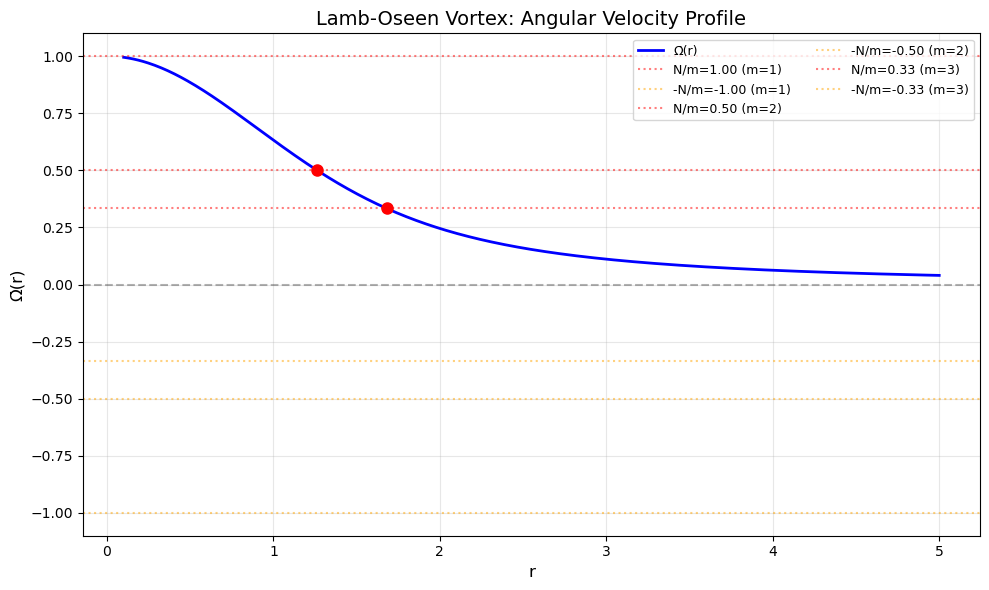


For Lamb-Oseen vortex:
  Ω̄_max ≈ 0.995 at r ≈ 0.100
  N = 1.0
  For m=2: Need Ω̄ = ±0.500


In [6]:
# Test the critical layer finding for different m values
from matplotlib import pyplot as plt

# Create a vortex instance
test_vortex = LambOseenVortex(bg_params.V_max, bg_params.r_core)

# Plot Omega_bar profile
r_test = np.linspace(0.1, 5, 500)
Omega_test = test_vortex.Omega_bar(r_test)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(r_test, Omega_test, 'b-', linewidth=2, label='Ω̄(r)')
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.grid(True, alpha=0.3)
ax.set_xlabel('r', fontsize=12)
ax.set_ylabel('Ω̄(r)', fontsize=12)
ax.set_title('Lamb-Oseen Vortex: Angular Velocity Profile', fontsize=14)

# Check critical layers for m = 1, 2, 3
N = bg_params.N
for m in [1, 2, 3]:
    r_cl = test_vortex.critical_layer_radius_quasi_stationary(m, N)
    target_pos = N / m
    target_neg = -N / m
    
    ax.axhline(target_pos, color='r', linestyle=':', alpha=0.5, label=f'N/m={target_pos:.2f} (m={m})')
    ax.axhline(target_neg, color='orange', linestyle=':', alpha=0.5, label=f'-N/m={target_neg:.2f} (m={m})')
    
    print(f"m={m}: Target Ω̄ = ±{N/m:.3f}, Found {len(r_cl)} critical layers at r = {r_cl}")
    
    # Mark found critical layers
    for r_c in r_cl:
        ax.plot(r_c, test_vortex.Omega_bar(np.array([r_c]))[0], 'ro', markersize=8)

ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

print("\nFor Lamb-Oseen vortex:")
print(f"  Ω̄_max ≈ {np.max(Omega_test):.3f} at r ≈ {r_test[np.argmax(Omega_test)]:.3f}")
print(f"  N = {N}")
print(f"  For m=2: Need Ω̄ = ±{N/2:.3f}")

### Step 2: Analyze Perturbation Spectrum

In [7]:
# Create analyzer
analyzer = PerturbationSpectrumAnalyzer(bg_params, pert_params)

print(f"\nCalculated vertical scale: H' = {analyzer.H_prime:.4f}")
print(f"Aspect ratio α = H'/L' = {analyzer.H_prime/pert_params.L_prime:.4f}")

# Analyze spectrum
dominant_modes, spectrum_data = analyzer.analyze_spectrum(threshold_factor=0.15, n_points=64)

# Group modes by magnitude
from collections import defaultdict
mode_groups = defaultdict(list)
for mode in dominant_modes:
    signature = (abs(mode['m']), round(abs(mode['kr']), 3), round(abs(mode['kz']), 3))
    mode_groups[signature].append(mode)

# Sort groups by max amplitude
sorted_groups = sorted(mode_groups.items(), key=lambda x: max(m['amplitude'] for m in x[1]), reverse=True)

print(f"\n{'=' * 85}")
print(f"UNIQUE WAVENUMBER COMBINATIONS: {len(sorted_groups)} (from {len(dominant_modes)} total modes)")
print(f"{'=' * 85}")
print(f"Expected: kr ~ 1/L' = {1/pert_params.L_prime:.3f}, kz ~ 1/H' = {1/analyzer.H_prime:.3f}")
print(f"\n{'Group':<7} {'|m|':>5} {'|kr|':>10} {'|kz|':>10} {'|k|':>10} {'Variants':>10} {'Max Amp':>12}")
print("-" * 85)
for group_idx, (signature, modes) in enumerate(sorted_groups[:10], 1):  # Show top 10 unique
    abs_m, abs_kr, abs_kz = signature
    k_total = np.sqrt(abs_kr**2 + abs_kz**2)
    max_amp = max(m['amplitude'] for m in modes)
    print(f"{group_idx:<7} {abs_m:>5} {abs_kr:>10.3f} {abs_kz:>10.3f} {k_total:>10.3f} {len(modes):>10} {max_amp:>12.2e}")
print("=" * 85)


Calculated vertical scale: H' = 0.2769
Aspect ratio α = H'/L' = 0.9230
Creating local Cartesian grid aligned with global cylindrical...
Generating Gaussian vortex fields...
Performing 3D FFT...
  Buoyancy max: 2.2261e-01, Vorticity max: 1.2335e+00
Identifying spectral peaks...

UNIQUE WAVENUMBER COMBINATIONS: 1199 (from 8090 total modes)
Expected: kr ~ 1/L' = 3.333, kz ~ 1/H' = 3.611

Group     |m|       |kr|       |kz|        |k|   Variants      Max Amp
-------------------------------------------------------------------------------------
1           6      2.062      3.350      3.934          8     7.15e+01
2           3      4.123      3.350      5.312          8     7.15e+01
3           5      3.093      3.350      4.560          8     7.14e+01
4           6      3.093      3.350      4.560          8     7.09e+01
5           5      4.123      3.350      5.312          8     7.09e+01
6           6      1.031      3.350      3.505          8     7.07e+01
7           2      4.123    

### Step 3: Visualize Perturbation and Spectrum

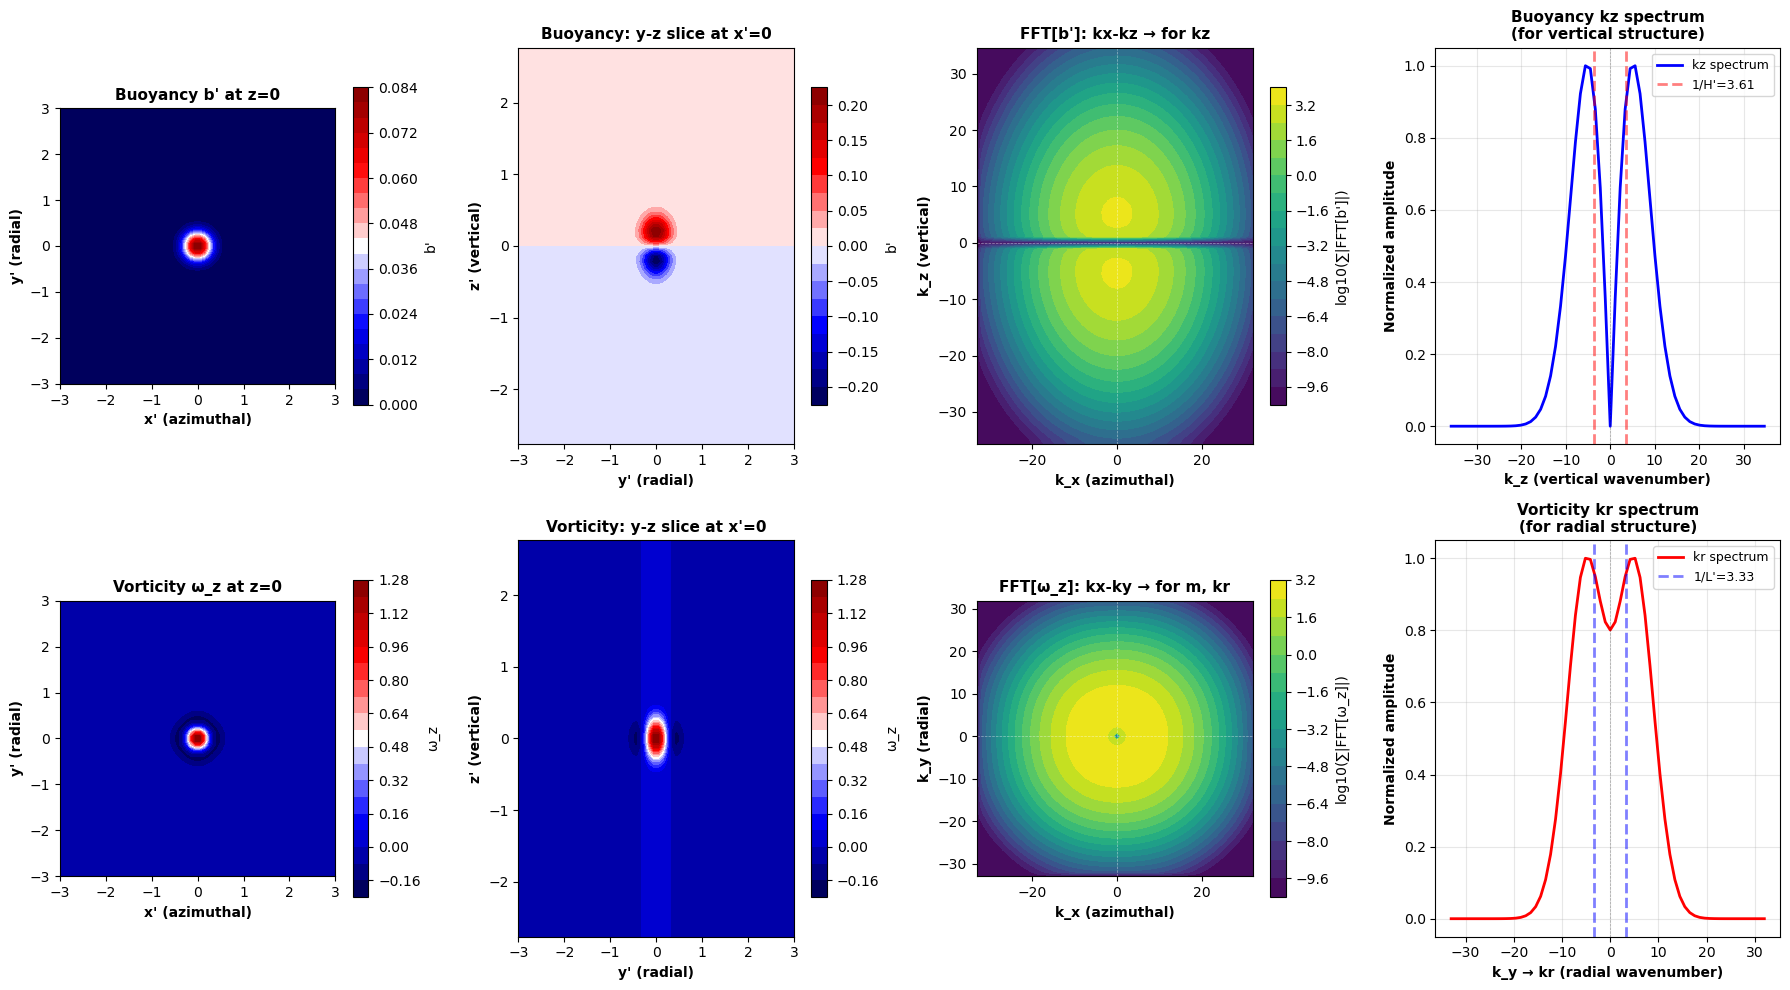


DOMINANT UNIQUE MODES (Grouped by |m|, |kr|, |kz|)
Note: Real fields → ±sign variations exist (shown count)
Expected: kr ~ 1/L' = 3.33, kz ~ 1/H' = 3.61
-------------------------------------------------------------------------------------
Group     |m|       |kr|       |kz|        |k|   Variants      Max Amp
-------------------------------------------------------------------------------------
1           6      2.062      3.350      5.610          8     7.15e+01
2           3      4.123      3.350      5.676          8     7.15e+01
3           5      3.093      3.350      5.648          8     7.14e+01
4           6      3.093      3.350      6.065          5     7.09e+01
5           5      4.123      3.350      6.272          1     7.09e+01



In [8]:
# ========== Visualize Perturbation Fields and Spectra ==========
fig = plt.figure(figsize=(18, 10))

# Get mid-plane slices
X = spectrum_data['X']
Y = spectrum_data['Y']
Z = spectrum_data['Z']
u = spectrum_data['u_prime']
v = spectrum_data['v_prime']
vort = spectrum_data['vorticity']
buoy = spectrum_data['buoyancy']

n_mid = X.shape[2] // 2  # Middle z-slice
n_x_mid = X.shape[0] // 2
n_y_mid = Y.shape[1] // 2

# Get wavenumber arrays and FFT magnitudes
kx = spectrum_data['kx']  # Azimuthal wavenumber (x' → θ)
ky = spectrum_data['ky']  # Radial wavenumber (y' → r)
kz = spectrum_data['kz']  # Vertical wavenumber
fft_vort_mag = spectrum_data['fft_vort_magnitude']
fft_buoy_mag = spectrum_data['fft_buoy_magnitude']

# ========== ROW 1: BUOYANCY ANALYSIS ==========
# Buoyancy field at z=0
ax1 = plt.subplot(2, 4, 1)
im1 = ax1.contourf(X[:, :, n_mid], Y[:, :, n_mid], buoy[:, :, n_mid], levels=20, cmap='seismic')
ax1.set_xlabel('x\' (azimuthal)', fontweight='bold')
ax1.set_ylabel('y\' (radial)', fontweight='bold')
ax1.set_title('Buoyancy b\' at z=0', fontweight='bold', fontsize=11)
ax1.set_aspect('equal')
plt.colorbar(im1, ax=ax1, label='b\'', shrink=0.8)

# Buoyancy y-z cross-section
ax2 = plt.subplot(2, 4, 2)
im2 = ax2.contourf(Y[n_x_mid, :, :], Z[n_x_mid, :, :], buoy[n_x_mid, :, :], levels=20, cmap='seismic')
ax2.set_xlabel('y\' (radial)', fontweight='bold')
ax2.set_ylabel('z\' (vertical)', fontweight='bold')
ax2.set_title('Buoyancy: y-z slice at x\'=0', fontweight='bold', fontsize=11)
plt.colorbar(im2, ax=ax2, label='b\'', shrink=0.8)

# Buoyancy spectrum: kx-kz (for vertical structure)
ax3 = plt.subplot(2, 4, 3)
spectrum_xz_buoy = np.sum(fft_buoy_mag, axis=1)  # Sum over ky
im3 = ax3.contourf(kx, kz, np.log10(spectrum_xz_buoy.T + 1e-10), levels=20, cmap='viridis')
ax3.set_xlabel('k_x (azimuthal)', fontweight='bold')
ax3.set_ylabel('k_z (vertical)', fontweight='bold')
ax3.set_title('FFT[b\']: kx-kz → for kz', fontweight='bold', fontsize=11)
ax3.axhline(0, color='white', linewidth=0.5, alpha=0.5, linestyle='--')
ax3.axvline(0, color='white', linewidth=0.5, alpha=0.5, linestyle='--')
plt.colorbar(im3, ax=ax3, label='log10(∑|FFT[b\']|)', shrink=0.8)

# Buoyancy spectrum: 1D profiles
ax4 = plt.subplot(2, 4, 4)
# kz spectrum (sum over kx and ky)
kz_spectrum = np.sum(fft_buoy_mag, axis=(0, 1))
ax4.plot(kz, kz_spectrum / np.max(kz_spectrum), 'b-', linewidth=2, label='kz spectrum')
ax4.axvline(0, color='k', linewidth=0.5, alpha=0.3, linestyle='--')
ax4.set_xlabel('k_z (vertical wavenumber)', fontweight='bold')
ax4.set_ylabel('Normalized amplitude', fontweight='bold')
ax4.set_title('Buoyancy kz spectrum\n(for vertical structure)', fontweight='bold', fontsize=11)
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=9)
# Mark expected kz ~ 1/H'
H_prime = analyzer.H_prime
ax4.axvline(1/H_prime, color='r', linewidth=2, alpha=0.5, linestyle='--', label=f'1/H\'={1/H_prime:.2f}')
ax4.axvline(-1/H_prime, color='r', linewidth=2, alpha=0.5, linestyle='--')
ax4.legend(fontsize=9)

# ========== ROW 2: VORTICITY ANALYSIS ==========
# Vorticity field at z=0
ax5 = plt.subplot(2, 4, 5)
im5 = ax5.contourf(X[:, :, n_mid], Y[:, :, n_mid], vort[:, :, n_mid], levels=20, cmap='seismic')
ax5.set_xlabel('x\' (azimuthal)', fontweight='bold')
ax5.set_ylabel('y\' (radial)', fontweight='bold')
ax5.set_title('Vorticity ω_z at z=0', fontweight='bold', fontsize=11)
ax5.set_aspect('equal')
plt.colorbar(im5, ax=ax5, label='ω_z', shrink=0.8)

# Vorticity y-z cross-section
ax6 = plt.subplot(2, 4, 6)
im6 = ax6.contourf(Y[n_x_mid, :, :], Z[n_x_mid, :, :], vort[n_x_mid, :, :], levels=20, cmap='seismic')
ax6.set_xlabel('y\' (radial)', fontweight='bold')
ax6.set_ylabel('z\' (vertical)', fontweight='bold')
ax6.set_title('Vorticity: y-z slice at x\'=0', fontweight='bold', fontsize=11)
plt.colorbar(im6, ax=ax6, label='ω_z', shrink=0.8)

# Vorticity spectrum: kx-ky (for horizontal structure)
ax7 = plt.subplot(2, 4, 7)
spectrum_xy_vort = np.sum(fft_vort_mag, axis=2)  # Sum over kz
im7 = ax7.contourf(kx, ky, np.log10(spectrum_xy_vort.T + 1e-10), levels=20, cmap='viridis')
ax7.set_xlabel('k_x (azimuthal)', fontweight='bold')
ax7.set_ylabel('k_y (radial)', fontweight='bold')
ax7.set_title('FFT[ω_z]: kx-ky → for m, kr', fontweight='bold', fontsize=11)
ax7.set_aspect('equal')
ax7.axhline(0, color='white', linewidth=0.5, alpha=0.5, linestyle='--')
ax7.axvline(0, color='white', linewidth=0.5, alpha=0.5, linestyle='--')
plt.colorbar(im7, ax=ax7, label='log10(∑|FFT[ω_z]|)', shrink=0.8)

# Vorticity spectrum: 1D profiles
ax8 = plt.subplot(2, 4, 8)
# Radial spectrum: sum over kx and kz, plot vs ky (→ kr)
kr_spectrum = np.sum(fft_vort_mag, axis=(0, 2))
ax8.plot(ky, kr_spectrum / np.max(kr_spectrum), 'r-', linewidth=2, label='kr spectrum')
ax8.axvline(0, color='k', linewidth=0.5, alpha=0.3, linestyle='--')
ax8.set_xlabel('k_y → kr (radial wavenumber)', fontweight='bold')
ax8.set_ylabel('Normalized amplitude', fontweight='bold')
ax8.set_title('Vorticity kr spectrum\n(for radial structure)', fontweight='bold', fontsize=11)
ax8.grid(True, alpha=0.3)
# Mark expected kr ~ 1/L'
L_prime = analyzer.pert.L_prime
ax8.axvline(1/L_prime, color='b', linewidth=2, alpha=0.5, linestyle='--', label=f'1/L\'={1/L_prime:.2f}')
ax8.axvline(-1/L_prime, color='b', linewidth=2, alpha=0.5, linestyle='--')
ax8.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ========== DOMINANT MODES: GROUPED BY MAGNITUDE ==========
print(f"\n{'='*85}")
print(f"DOMINANT UNIQUE MODES (Grouped by |m|, |kr|, |kz|)")
print(f"{'='*85}")
print(f"Note: Real fields → ±sign variations exist (shown count)")
print(f"Expected: kr ~ 1/L' = {1/L_prime:.2f}, kz ~ 1/H' = {1/H_prime:.2f}")
print(f"{'-'*85}")

# Group modes by magnitude signature
from collections import defaultdict
mode_groups = defaultdict(list)

for mode in dominant_modes[:30]:  # Look at more modes to find groups
    # Create signature based on absolute values
    signature = (
        np.abs(mode['m']),
        round(np.abs(mode['kr']), 3),
        round(np.abs(mode['kz']), 3)
    )
    mode_groups[signature].append(mode)

# Sort groups by maximum amplitude in each group
sorted_groups = sorted(mode_groups.items(), 
                       key=lambda x: max(m['amplitude'] for m in x[1]), 
                       reverse=True)

print(f"{'Group':<7} {'|m|':>5} {'|kr|':>10} {'|kz|':>10} {'|k|':>10} {'Variants':>10} {'Max Amp':>12}")
print(f"{'-'*85}")

for group_idx, (signature, modes) in enumerate(sorted_groups[:10]):
    abs_m, abs_kr, abs_kz = signature
    k_total = np.sqrt(abs_kr**2 + (abs_m/analyzer.pert.r0)**2 + abs_kz**2)
    max_amp = max(m['amplitude'] for m in modes)
    
    print(f"{group_idx+1:<7} {abs_m:>5.0f} {abs_kr:>10.3f} {abs_kz:>10.3f} {k_total:>10.3f} "
          f"{len(modes):>10} {max_amp:>12.2e}")

print(f"{'='*85}\n")

### Step 4: Trace Wave Packets for Dominant Modes

In [17]:
# Create ray tracer
tracer = WavePacketRayTracer(bg_params)

# ========== SMART MODE SELECTION ==========
# Filter out redundant modes:
# 1. Since fields are real, complex conjugates exist (kr, m, kz) and (-kr, -m, -kz) are equivalent
# 2. Remove duplicate magnitude combinations
# 3. Select diverse modes with different (|m|, |kr|, |kz|)

print(f"\n{'=' * 60}")
print(f"SELECTING MODES FOR RAY TRACING")
print(f"{'=' * 60}")

# First, collect all modes with |m| <= 3 and non-DC wavenumbers
filtered_modes = []
for mode in dominant_modes:
    # Skip modes with very small wavenumbers (near DC)
    if np.abs(mode['kr']) < 0.1 or np.abs(mode['kz']) < 0.1:
        continue
    
    # Filter by |m| <= 3
    if np.abs(mode['m']) <= 3:
        filtered_modes.append(mode)

print(f"Found {len(filtered_modes)} modes with |m| <= 3")

# Group by magnitude signature and keep strongest from each group
from collections import defaultdict
mode_groups = defaultdict(list)
for mode in filtered_modes:
    signature = (
        np.abs(mode['m']),
        round(np.abs(mode['kr']), 3),
        round(np.abs(mode['kz']), 3)
    )
    mode_groups[signature].append(mode)

# Get distinct modes (strongest from each group)
distinct_modes = []
for signature, modes in mode_groups.items():
    # Pick the mode with highest amplitude from this group
    strongest = max(modes, key=lambda m: m['amplitude'])
    distinct_modes.append(strongest)

# Sort by amplitude and take top 3
distinct_modes.sort(key=lambda m: m['amplitude'], reverse=True)
top_3_modes = distinct_modes[:3]

print(f"Found {len(distinct_modes)} distinct magnitude combinations")
print(f"Selecting top 3 for ray tracing\n")
print(f"Top 3 wavenumber magnitude combinations:")
print(f"{'-'*70}")
print(f"{'#':<4} {'|m|':>5} {'|kr|':>10} {'|kz|':>10} {'|k|':>10} {'Amplitude':>12}")
print(f"{'-'*70}")
for i, mode in enumerate(top_3_modes):
    k_total = np.sqrt(mode['kr']**2 + (mode['m']/analyzer.pert.r0)**2 + mode['kz']**2)
    print(f"{i+1:<4} {np.abs(mode['m']):>5.0f} {np.abs(mode['kr']):>10.3f} {np.abs(mode['kz']):>10.3f} "
          f"{k_total:>10.3f} {mode['amplitude']:>12.2e}")
print(f"{'-'*70}")

# For each magnitude combination, create two modes: kr > 0 and kr < 0
# Physical reasoning: kr sign determines radial propagation direction (inward vs outward)
# while m and kz signs don't affect dynamics (just rotation/vertical direction)
modes_to_trace = []
for mode in top_3_modes:
    abs_m = np.abs(mode['m'])
    abs_kr = np.abs(mode['kr'])
    abs_kz = np.abs(mode['kz'])
    
    # Mode with kr > 0 (outward propagation)
    mode_kr_pos = {
        'kr': abs_kr,
        'm': int(abs_m),  # Use positive m
        'kz': abs_kz,     # Use positive kz
        'amplitude': mode['amplitude']
    }
    modes_to_trace.append(mode_kr_pos)
    
    # Mode with kr < 0 (inward propagation)
    mode_kr_neg = {
        'kr': -abs_kr,
        'm': int(abs_m),  # Same m
        'kz': abs_kz,     # Same kz
        'amplitude': mode['amplitude']
    }
    modes_to_trace.append(mode_kr_neg)

print(f"\nCreated {len(modes_to_trace)} ray tracing cases (3 magnitudes × 2 kr directions):")
print(f"{'-'*85}")
print(f"{'Case':<6} {'|m|':>5} {'kr':>10} {'|kz|':>10} {'Direction':>15} {'Amplitude':>12}")
print(f"{'-'*85}")
for i, mode in enumerate(modes_to_trace):
    direction = "Outward" if mode['kr'] > 0 else "Inward"
    print(f"{i+1:<6} {np.abs(mode['m']):>5} {mode['kr']:>10.3f} {mode['kz']:>10.3f} {direction:>15} {mode['amplitude']:>12.2e}")
print(f"{'-'*85}")

print(f"\n{'=' * 85}")
print(f"TRACING {len(modes_to_trace)} WAVE PACKETS (3 magnitudes × 2 radial directions)")
print(f"Integration: dt=0.02, max_steps=5000, max_time=100")
print(f"{'=' * 85}\n")

# Trace rays with longer integration time
import sys
import time
trajectories = []
for i, mode in enumerate(modes_to_trace):
    # Force flush and small delay to prevent Jupyter output buffering bug
    print(f"\nMode {i+1}/{len(modes_to_trace)}: kr={mode['kr']:.4f}, m={mode['m']}, kz={mode['kz']:.4f} [START]")
    sys.stdout.flush()
    time.sleep(0.01)  # Small delay to force proper output ordering
    
    trajectory = tracer.trace_ray(
        r_start=pert_params.r0,
        z_start=pert_params.z0,
        theta_start=pert_params.theta0,
        kr_start=mode['kr'],
        m=mode['m'],
        kz=mode['kz'],
        dt=0.005,
        num_steps=40000  # total time = 0.005 * 40000 = 200 units
    )
    
    trajectories.append(trajectory)
    
    # Trajectory statistics
    r_start, r_end = trajectory['r'][0], trajectory['r'][-1]
    z_start, z_end = trajectory['z'][0], trajectory['z'][-1]
    dr = r_end - r_start
    dz = z_end - z_start
    total_distance = np.sqrt(np.sum(np.diff(trajectory['r'])**2 + np.diff(trajectory['z'])**2))
    
    print(f"  Trajectory length: {len(trajectory['r'])} points")
    print(f"  Displacement: Δr={dr:+.3f}, Δz={dz:+.3f}, total path length={total_distance:.3f}")
    if trajectory['r_critical_wave_packet'] is not None:
        print(f"  ⚠ Wave packet reached its critical layer (Φ²+N²→0) at r = {trajectory['r_critical_wave_packet']:.3f}")
    if np.any(trajectory['quasi_stationary_CL_mask']):
        print(f"  ○ Crossed quasi-stationary CL: {np.sum(trajectory['quasi_stationary_CL_mask'])} points")
    print(f"Mode {i+1}/{len(modes_to_trace)}: [COMPLETE]")
    sys.stdout.flush()

print(f"\n{'=' * 60}")
print(f"Ray tracing completed: {len(trajectories)} trajectories")
print(f"{'=' * 60}")


SELECTING MODES FOR RAY TRACING
Found 2036 modes with |m| <= 3
Found 306 distinct magnitude combinations
Selecting top 3 for ray tracing

Top 3 wavenumber magnitude combinations:
----------------------------------------------------------------------
#      |m|       |kr|       |kz|        |k|    Amplitude
----------------------------------------------------------------------
1        3      4.123      3.350      5.677     7.15e+01
2        2      4.123      3.350      5.478     7.07e+01
3        0      5.154      3.350      6.147     7.02e+01
----------------------------------------------------------------------

Created 6 ray tracing cases (3 magnitudes × 2 kr directions):
-------------------------------------------------------------------------------------
Case     |m|         kr       |kz|       Direction    Amplitude
-------------------------------------------------------------------------------------
1          3      4.123      3.350         Outward     7.15e+01
2          3    

Tracing ray for mode (kr=4.123, m=3, kz=3.350)...
Starting at (r, θ, z) = (1.500, 0.000, 0.000)
Quasi-stationary critical layers at r = [1.679714074514492]
Ray tracing completed: 40001 points
  Trajectory length: 40001 points
  Displacement: Δr=-0.356, Δz=+0.638, total path length=0.011
Mode 1/6: [COMPLETE]

Mode 2/6: kr=-4.1233, m=3, kz=3.3505 [START]
Ray tracing completed: 40001 points
  Trajectory length: 40001 points
  Displacement: Δr=-0.356, Δz=+0.638, total path length=0.011
Mode 1/6: [COMPLETE]

Mode 2/6: kr=-4.1233, m=3, kz=3.3505 [START]
Tracing ray for mode (kr=-4.123, m=3, kz=3.350)...
Starting at (r, θ, z) = (1.500, 0.000, 0.000)
Quasi-stationary critical layers at r = [1.679714074514492]
Tracing ray for mode (kr=-4.123, m=3, kz=3.350)...
Starting at (r, θ, z) = (1.500, 0.000, 0.000)
Quasi-stationary critical layers at r = [1.679714074514492]
Ray tracing completed: 40001 points
  Trajectory length: 40001 points
  Displacement: Δr=-0.356, Δz=-0.638, total path length=0.011


### Step 5: Visualize Ray Trajectories

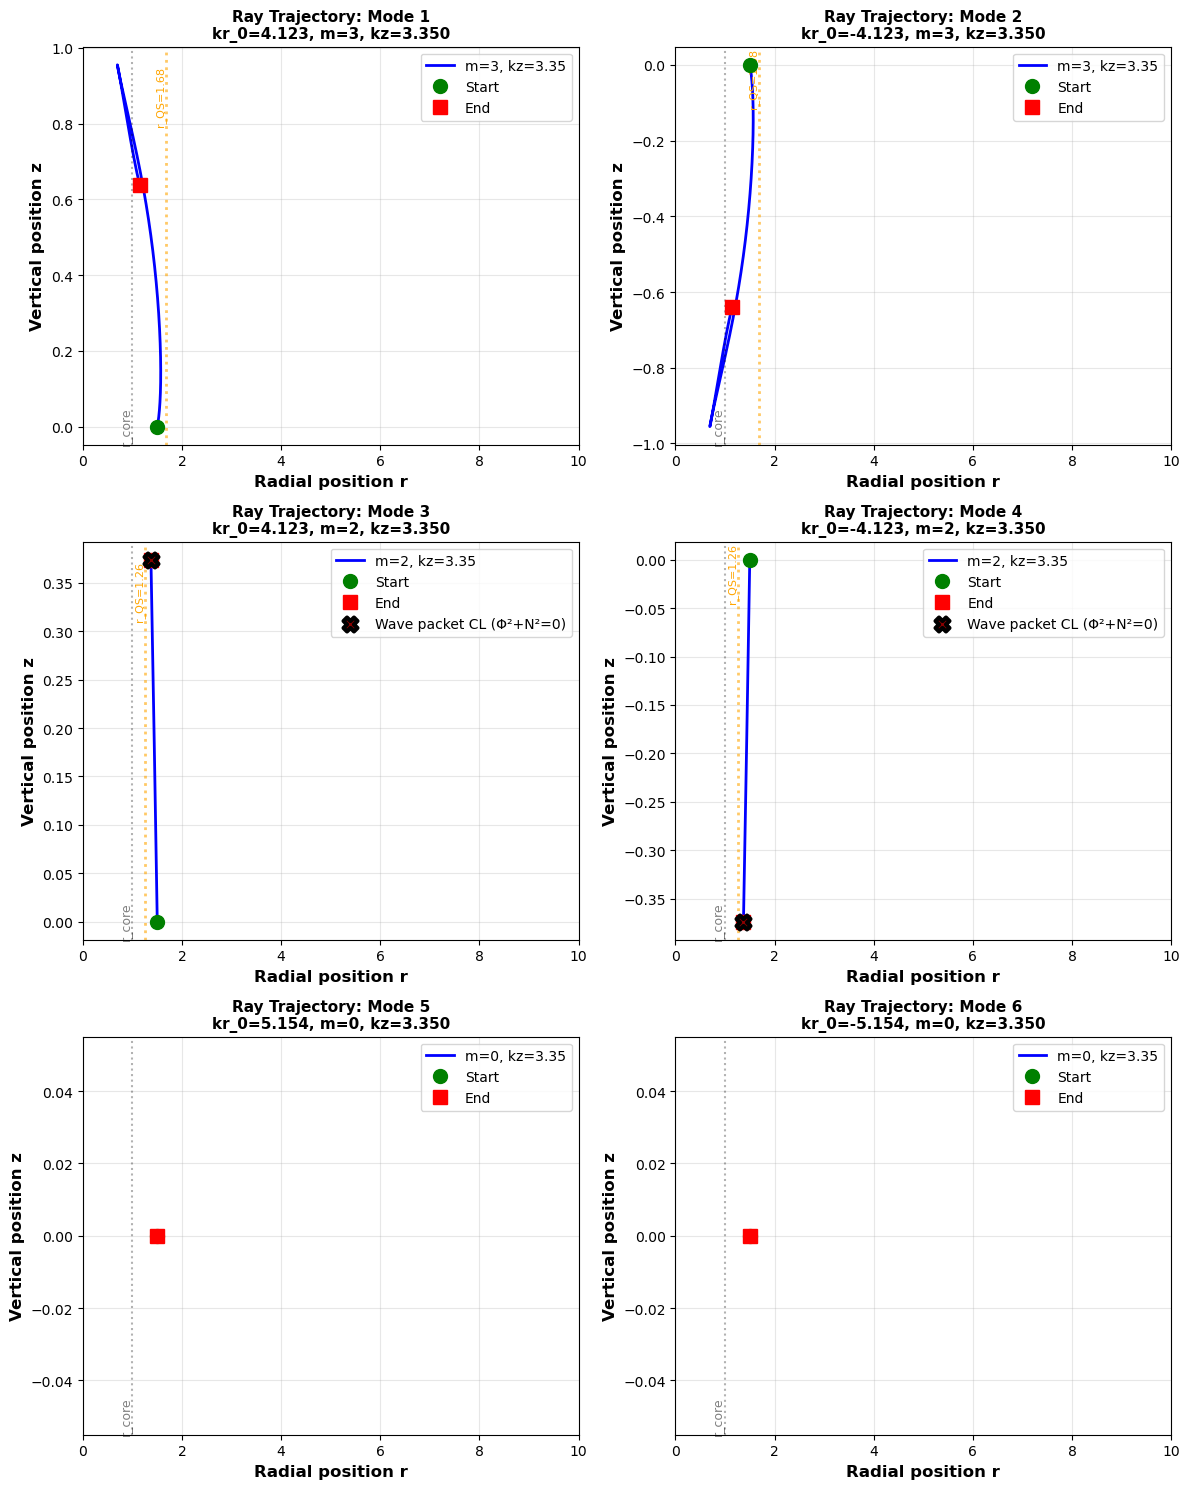

In [18]:
# ========== Plot Ray Trajectories in r-z Plane ==========
# Arrange plots in rows of 2
n_plots = len(trajectories)
n_cols = 2
n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5*n_rows))

# Flatten axes array for easier indexing
if n_plots == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()

colors = ['blue']

for i, traj in enumerate(trajectories):
    ax = axes[i]
    # Plot trajectory
    m_value = traj['m'][0]  # m is conserved, so we can use first value
    kz_value = traj['kz'][0]  # kz is also conserved
    
    ax.plot(traj['r'], traj['z'], '-', color=colors[0], linewidth=2, 
            label=f"m={m_value}, kz={kz_value:.2f}")
    
    # Mark starting point
    ax.plot(traj['r'][0], traj['z'][0], 'go', markersize=10, label='Start', zorder=5)
    
    # Mark ending point
    ax.plot(traj['r'][-1], traj['z'][-1], 'rs', markersize=10, label='End', zorder=5)
    
    # Highlight wave packet's own critical layer (Φ²+N²→0) - RED X (terminates integration)
    if np.any(traj['critical_mask']):
        critical_indices = np.where(traj['critical_mask'])[0]
        ax.scatter(traj['r'][critical_indices], traj['z'][critical_indices], 
                  color='darkred', s=100, marker='X', linewidths=3, edgecolors='black',
                  label='Wave packet CL (Φ²+N²=0)', zorder=10)
    
    # Highlight quasi-stationary critical layer crossings (ω≈0) - YELLOW CIRCLES (non-terminating)
    if np.any(traj['quasi_stationary_CL_mask']):
        qs_indices = np.where(traj['quasi_stationary_CL_mask'])[0]
        ax.scatter(traj['r'][qs_indices], traj['z'][qs_indices], 
                  color='yellow', s=60, marker='o', edgecolors='black', linewidths=1.5,
                  label='Quasi-stationary CL (ω≈0)', zorder=9, alpha=0.7)
    
    # Plot quasi-stationary critical layer radii (vertical dashed lines)
    for r_c in traj['r_critical_quasi_stationary']:
        ax.axvline(r_c, color='orange', linestyle=':', alpha=0.6, linewidth=2)
        ax.text(r_c, ax.get_ylim()[1]*0.95, f'r_QS={r_c:.2f}', 
                rotation=90, va='top', ha='right', fontsize=8, color='orange')
    
    # Formatting
    ax.set_xlabel('Radial position r', fontweight='bold', fontsize=12)
    ax.set_ylabel('Vertical position z', fontweight='bold', fontsize=12)
    ax.set_title(f'Ray Trajectory: Mode {i+1}\n' + 
                 f'kr_0={traj["kr"][0]:.3f}, m={m_value}, kz={kz_value:.3f}',
                 fontweight='bold', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, max(10, np.max(traj['r'])*1.1))
    
    # Add vortex core marker
    ax.axvline(bg_params.r_core, color='black', linestyle=':', alpha=0.3, linewidth=1.5)
    ax.text(bg_params.r_core, ax.get_ylim()[0], 'r_core', 
            rotation=90, va='bottom', ha='right', fontsize=9, alpha=0.5)

# Hide unused subplots
for i in range(n_plots, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Step 6: Analyze Group Velocity Along Rays

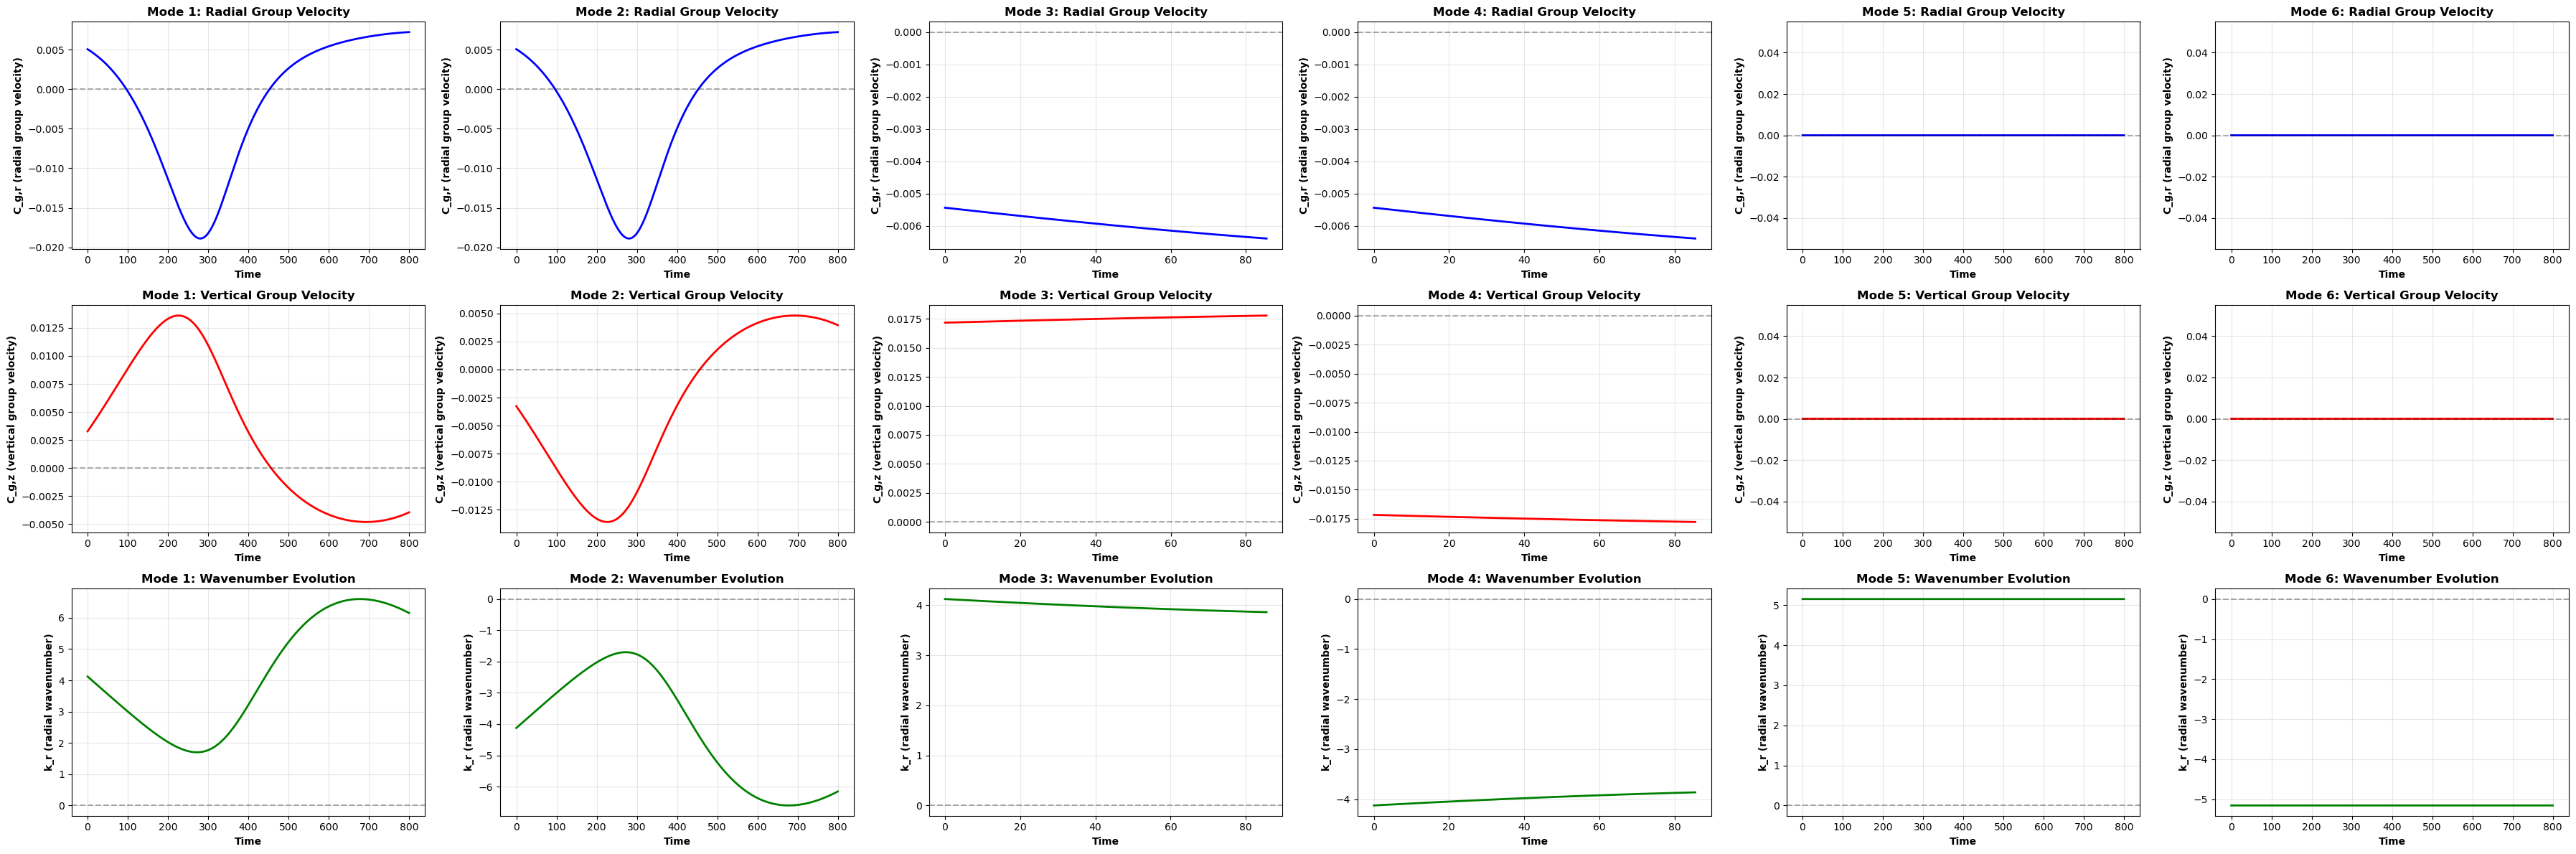

In [19]:
# ========== Plot Group Velocity and Wavenumber Evolution ==========
fig, axes = plt.subplots(3, len(trajectories), figsize=(6*len(trajectories), 12))

if len(trajectories) == 1:
    axes = axes.reshape(3, 1)

for i, traj in enumerate(trajectories):
    # Time axis
    t = np.arange(len(traj['Cg_r'])) * 0.02  # dt = 0.02
    
    # Get critical layer indices for marking
    critical_indices = np.where(traj['critical_mask'][:-1])[0]  # -1 because Cg arrays are shorter
    
    # Plot Cg_r
    axes[0, i].plot(t, traj['Cg_r'], 'b-', linewidth=2)
    if len(critical_indices) > 0:
        axes[0, i].scatter(t[critical_indices], traj['Cg_r'][critical_indices], 
                          color='red', s=30, marker='x', linewidths=2, zorder=5)
    axes[0, i].axhline(0, color='k', linestyle='--', alpha=0.3)
    axes[0, i].set_xlabel('Time', fontweight='bold')
    axes[0, i].set_ylabel('C_g,r (radial group velocity)', fontweight='bold')
    axes[0, i].set_title(f'Mode {i+1}: Radial Group Velocity', fontweight='bold')
    axes[0, i].grid(True, alpha=0.3)
    
    # Plot Cg_z
    axes[1, i].plot(t, traj['Cg_z'], 'r-', linewidth=2)
    if len(critical_indices) > 0:
        axes[1, i].scatter(t[critical_indices], traj['Cg_z'][critical_indices], 
                          color='red', s=30, marker='x', linewidths=2, zorder=5)
    axes[1, i].axhline(0, color='k', linestyle='--', alpha=0.3)
    axes[1, i].set_xlabel('Time', fontweight='bold')
    axes[1, i].set_ylabel('C_g,z (vertical group velocity)', fontweight='bold')
    axes[1, i].set_title(f'Mode {i+1}: Vertical Group Velocity', fontweight='bold')
    axes[1, i].grid(True, alpha=0.3)
    
    # Plot kr evolution
    t_kr = np.arange(len(traj['kr'])) * 0.02
    axes[2, i].plot(t_kr, traj['kr'], 'g-', linewidth=2)
    if len(critical_indices) > 0:
        axes[2, i].scatter(t_kr[critical_indices], traj['kr'][critical_indices], 
                          color='red', s=30, marker='x', linewidths=2, 
                          label='Critical layer', zorder=5)
    axes[2, i].axhline(0, color='k', linestyle='--', alpha=0.3)
    axes[2, i].set_xlabel('Time', fontweight='bold')
    axes[2, i].set_ylabel('k_r (radial wavenumber)', fontweight='bold')
    axes[2, i].set_title(f'Mode {i+1}: Wavenumber Evolution', fontweight='bold')
    axes[2, i].grid(True, alpha=0.3)
    if len(critical_indices) > 0:
        axes[2, i].legend()

plt.tight_layout()
plt.show()